<a href="https://colab.research.google.com/github/sonaldesai23/casting-defect-detection/blob/main/Casting_Product_Defect_Detection_using_CNNipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install -q kaggle

import os
os.environ['KAGGLE_USERNAME'] = "your_kaggle_username"  # Replace with your Kaggle username
os.environ['KAGGLE_KEY'] = "your_kaggle_api_key"        # Replace with your Kaggle API key

!kaggle datasets download -d ravirajsinh45/real-life-industrial-dataset-of-casting-product
!unzip -q real-life-industrial-dataset-of-casting-product.zip -d casting_data


Dataset URL: https://www.kaggle.com/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
 73% 73.0M/100M [00:00<00:00, 764MB/s]
100% 100M/100M [00:00<00:00, 590MB/s] 


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import keras, os
# The ImageDataGenerator is now part of tensorflow.keras.utils.
# You can import it using tf.keras.utils.image_dataset_from_directory or tf.keras.preprocessing.image_dataset_from_directory
# This also applies to other image preprocessing classes in Keras.
from tensorflow.keras.utils import image_dataset_from_directory
# If you need the ImageDataGenerator class for other purposes, import it using:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential, model_from_json
from keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense
from tensorflow.keras.applications import Xception

In [ ]:
train = train_data_gen.flow_from_directory(
    directory="/content/casting_data/casting_data/casting_data/train",  # Updated path
    target_size=(256, 256),
    batch_size=32,
    class_mode='binary'
)

In [ ]:

test = train_data_gen.flow_from_directory(
    directory="/content/casting_data/casting_data/casting_data/test",
    target_size=(256, 256),
    batch_size=32,
    class_mode='binary'
)

Found 715 images belonging to 2 classes.


Transfer Learning Model with Xception

In [ ]:

xcept = Xception(input_shape=(256, 256, 3), include_top=False, weights='imagenet')

for layer in xcept.layers:
    layer.trainable = False

model = Sequential([
    xcept,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 8, 8, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    33,554,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,416,425 (207.58 MB)

 Trainable params: 33,554,945 (128.00 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

Train Model

In [ ]:
model.fit(train, epochs=10, steps_per_epoch=7, validation_data=test, validation_steps=len(test))


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 268s 42s/step - accuracy: 0.5870 - loss: 11.0839 - val_accuracy: 0.6364 - val_loss: 6.7258
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 248s 40s/step - accuracy: 0.7263 - loss: 4.9857 - val_accuracy: 0.7944 - val_loss: 4.3643
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 254s 41s/step - accuracy: 0.8235 - loss: 4.4683 - val_accuracy: 0.9147 - val_loss: 0.8426
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 245s 39s/step - accuracy: 0.8420 - loss: 3.2180 - val_accuracy: 0.7524 - val_loss: 5.0643
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 263s 42s/step - accuracy: 0.8227 - loss: 4.7164 - val_accuracy: 0.8112 - val_loss: 2.6945
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 264s 42s/step - accuracy: 0.8384 - loss: 2.3360 - val_accuracy: 0.9497 - val_loss: 0.6186
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 245s 40s/step - accuracy: 0.9375 - loss: 0.4097 - val_accuracy: 0.9566 - val_loss: 0.3650
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 263s 42s/step - accuracy: 0.9669 - loss: 0.2761 - val_accuracy: 0.9650 - val_loss

Visualization

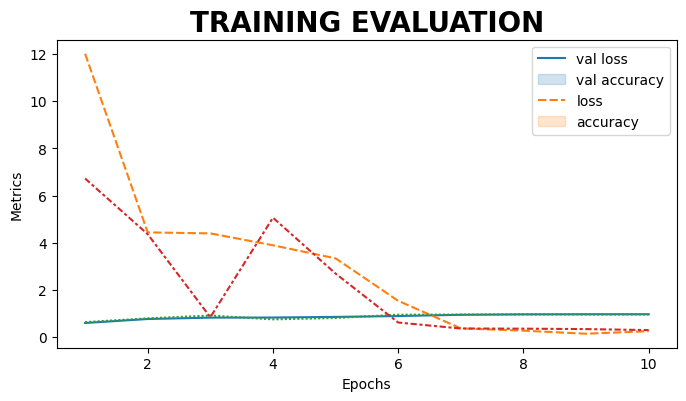

In [ ]:
plt.subplots(figsize=(8, 4))
sns.lineplot(data=pd.DataFrame(model.history.history, index=range(1, 1+len(model.history.epoch))))
plt.title("TRAINING EVALUATION", fontweight="bold", fontsize=20)
plt.xlabel("Epochs")
plt.ylabel("Metrics")
plt.legend(labels=['val loss', 'val accuracy', 'loss', 'accuracy'])
plt.show()


Save Model

In [ ]:

model_json = model.to_json()
with open("model.json", "w") as json_file:
    json_file.write(model_json)

model.save_weights("model.weights.h5")


Prediction from User Input Image

In [ ]:

from keras.preprocessing import image

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(256, 256))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    if prediction[0][0] > 0.5:
        print("✅ Prediction: Defective")
    else:
        print("✅ Prediction: Non-defective")


In [ ]:
# Example usage
img_path = input("Enter the path to the image file: ")
predict_image(img_path)


Enter the path to the image file: /content/Screenshot 2025-05-02 112528.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
✅ Prediction: Non-defective


In [ ]:
# After training
history = model.fit(...)

# Get the last validation accuracy
val_acc = history.history['val_accuracy'][-1] * 100
print(f"Final Validation Accuracy: {val_acc:.2f}%")
